In [18]:
import pandas as pd
import numpy as np
import tkinter as tk
import matplotlib.pyplot as plt
import time

from pathlib import Path
from tkinter import filedialog
from scipy.stats import gaussian_kde
from sklearn.model_selection import KFold
from sklearn.neighbors import KernelDensity


In [19]:
def load_dataframe_from_path(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    ext = path.suffix.lower()

    if ext == ".csv":
        df = pd.read_csv(path, delimiter=",")
        
    elif ext in [".otus", ".txt", ".meta", ".taxonomy"]:
        df = pd.read_csv(path, sep="\t")
        
    else:
        raise ValueError(
            f"Formato no soportado: {ext}. "
            "Usa archivos .csv, .otus, .txt, .meta o .taxonomy"
        )

    return df


def load_multiple_dataframes():
    root = tk.Tk()
    root.withdraw()  
    root.attributes("-topmost", True)  

    file_paths = filedialog.askopenfilenames(
        title="Selecciona uno o varios datasets",
        filetypes=[
            ("Archivos soportados", "*.csv *.otus *.txt *.meta *.taxonomy"),
            ("CSV", "*.csv"),
            ("OTUS", "*.otus"),
            ("TXT", "*.txt"),
            ("META", "*.meta"),
            ("TAXONOMY", "*.taxonomy"),
            ("Todos los archivos", "*.*")
        ]
    )

    if not file_paths:
        print("No se seleccionó ningún archivo.")
        return {}

    dataframes = {}

    for file_path in file_paths:
        path = Path(file_path)
        try:
            df = load_dataframe_from_path(path)
            dataframes[path.stem] = df
            print(f"Cargado: {path.name} -> shape {df.shape}")
        except Exception as e:
            print(f"Error al cargar {path.name}: {e}")

    return dataframes

In [20]:
dfs = load_multiple_dataframes()

if not dfs:
    print("No se cargó ningún archivo.")
else:
    for nombre, df in dfs.items():
        print(f"\nArchivo cargado: {nombre}")
        print(f"Shape del DataFrame: {df.shape}")
        print(f"Columnas: {df.columns.tolist()[:10]}{' ...' if len(df.columns) > 10 else ''}")

Cargado: otu_data_converted.csv -> shape (441, 4739)

Archivo cargado: otu_data_converted
Shape del DataFrame: (441, 4739)
Columnas: ['ID', 'Otu00001', 'Otu00002', 'Otu00003', 'Otu00004', 'Otu00005', 'Otu00006', 'Otu00007', 'Otu00008', 'Otu00009'] ...


In [21]:
def get_otu_positive_values(dfs, data_df_name="otu_data_converted"):
    if data_df_name not in dfs:
        raise KeyError(f"No existe '{data_df_name}' en dfs. Disponibles: {list(dfs.keys())}")

    df = dfs[data_df_name].copy()
    values = df.select_dtypes(include=[np.number]).to_numpy(dtype=float).ravel()
    values = values[np.isfinite(values)]
    positives = values[values > 0]

    if positives.size == 0:
        raise ValueError(f"'{data_df_name}' no contiene valores numericos positivos.")

    return positives, df.shape


def suggest_grid_size(n_values):
    if n_values <= 250_000:
        return 1000
    if n_values <= 1_000_000:
        return 1500
    return 2000


def make_log_grid(values, grid_size, bandwidth):
    positives = np.asarray(values, dtype=float).ravel()
    positives = positives[np.isfinite(positives)]
    positives = positives[positives > 0]

    if positives.size == 0:
        raise ValueError("Se requiere al menos un valor positivo.")
    if bandwidth <= 0:
        raise ValueError("El bandwidth debe ser positivo.")

    lower = max(float(np.min(positives)) * 1e-3, 1e-12)
    upper = float(np.max(positives) + 8.0 * bandwidth)
    return np.logspace(np.log10(lower), np.log10(upper), int(grid_size))


In [22]:
def prepare_values(values):
    arr = np.asarray(values, dtype=float).ravel()
    arr = arr[np.isfinite(arr)]

    if arr.size < 2:
        raise ValueError("Se requieren al menos 2 valores finitos.")
    if np.nanstd(arr, ddof=1) <= 0:
        raise ValueError("No se puede estimar bandwidth con varianza cero.")

    return arr


def scott_h(values):
    values = prepare_values(values)
    std = float(np.std(values, ddof=1))
    return float(gaussian_kde(values, bw_method="scott").factor * std)


def silverman_h(values):
    values = prepare_values(values)
    std = float(np.std(values, ddof=1))
    return float(gaussian_kde(values, bw_method="silverman").factor * std)


def cv_loglik(values, kernel="gaussian", cv_folds=3, n_subsample=1000, n_bw=8, bw_lo_factor=0.02, bw_hi_factor=3.0, seed=42):
    values = prepare_values(values)
    rng = np.random.default_rng(seed)
    k = min(int(n_subsample), len(values))
    folds = min(int(cv_folds), k)

    if folds < 2:
        raise ValueError("Se requieren al menos 2 observaciones para validacion cruzada.")

    sample = values[rng.choice(len(values), size=k, replace=False)].reshape(-1, 1)
    bw_scott_abs = scott_h(values)
    bw_min = max(0.5, bw_scott_abs * bw_lo_factor)
    bw_max = bw_scott_abs * bw_hi_factor
    bw_grid = np.geomspace(bw_min, bw_max, int(n_bw))

    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
    scores = np.zeros(len(bw_grid))

    for i, bw in enumerate(bw_grid):
        fold_scores = []
        for train_idx, val_idx in kf.split(sample):
            kde = KernelDensity(kernel=kernel, bandwidth=bw, breadth_first=False)
            kde.fit(sample[train_idx])
            fold_scores.append(kde.score(sample[val_idx]))
        scores[i] = float(np.mean(fold_scores))

    best_idx = int(np.argmax(scores))
    return float(bw_grid[best_idx]), bw_grid, scores


def estimate_cv_by_kernel(values, kernels, cv_folds=3, n_subsample=1000, n_bw=8):
    rows = []
    score_curves = {}

    for kernel in kernels:
        best_bw, bw_grid, scores = cv_loglik(
            values,
            kernel=kernel,
            cv_folds=cv_folds,
            n_subsample=n_subsample,
            n_bw=n_bw,
        )
        best_idx = int(np.argmax(scores))
        rows.append({
            "kernel": kernel,
            "bandwidth_cv": best_bw,
            "score_cv": float(scores[best_idx]),
        })
        score_curves[kernel] = (bw_grid, scores)

    return pd.DataFrame(rows), score_curves


In [23]:
def get_kernels():
    return ("gaussian", "epanechnikov", "tophat", "exponential", "linear", "cosine")


def get_color_map():
    return {
        "gaussian": "#4c78a8",
        "epanechnikov": "#e45756",
        "tophat": "#f58518",
        "exponential": "#54a24b",
        "linear": "#b279a2",
        "cosine": "#9d755d",
    }


def positive_mass(pdf, x_grid):
    return float(np.trapezoid(pdf, x_grid))


def normalize_conditional(pdf, x_grid):
    mass = positive_mass(pdf, x_grid)

    if not np.isfinite(mass) or mass <= 0:
        raise ValueError("La densidad KDE tiene masa no positiva o no finita.")

    return pdf / mass, mass


def mode_kde(pdf, x_grid):
    return float(x_grid[int(np.argmax(pdf))])


def evaluate_kde_gaussian_fast(data, x_grid, bandwidth):
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth, breadth_first=False)
    kde.fit(np.asarray(data, dtype=float).reshape(-1, 1))
    return np.exp(kde.score_samples(np.asarray(x_grid, dtype=float).reshape(-1, 1)))


def sorted_prefix(data):
    sorted_data = np.sort(np.asarray(data, dtype=float))
    prefix_1 = np.concatenate(([0.0], np.cumsum(sorted_data)))
    prefix_2 = np.concatenate(([0.0], np.cumsum(sorted_data * sorted_data)))
    return sorted_data, prefix_1, prefix_2


def evaluate_finite_support_fast(data, x_grid, bandwidth, kernel):
    sorted_data, prefix_1, prefix_2 = sorted_prefix(data)
    n = float(sorted_data.size)
    x = np.asarray(x_grid, dtype=float)
    left = np.searchsorted(sorted_data, x - bandwidth, side="left")
    right = np.searchsorted(sorted_data, x + bandwidth, side="right")
    count = (right - left).astype(float)

    if kernel == "tophat":
        return 0.5 * count / (n * bandwidth)

    if kernel == "epanechnikov":
        sum_1 = prefix_1[right] - prefix_1[left]
        sum_2 = prefix_2[right] - prefix_2[left]
        sq_dist = count * x * x - 2.0 * x * sum_1 + sum_2
        return 0.75 * (count - sq_dist / (bandwidth * bandwidth)) / (n * bandwidth)

    if kernel == "linear":
        mid = np.searchsorted(sorted_data, x, side="right")
        mid = np.minimum(np.maximum(mid, left), right)
        left_count = (mid - left).astype(float)
        right_count = (right - mid).astype(float)
        left_sum = prefix_1[mid] - prefix_1[left]
        right_sum = prefix_1[right] - prefix_1[mid]
        abs_dist = x * left_count - left_sum + right_sum - x * right_count
        return (count - abs_dist / bandwidth) / (n * bandwidth)

    if kernel == "cosine":
        c = np.pi / (2.0 * bandwidth)
        prefix_cos = np.concatenate(([0.0], np.cumsum(np.cos(c * sorted_data))))
        prefix_sin = np.concatenate(([0.0], np.cumsum(np.sin(c * sorted_data))))
        sum_cos = prefix_cos[right] - prefix_cos[left]
        sum_sin = prefix_sin[right] - prefix_sin[left]
        values = np.cos(c * x) * sum_cos + np.sin(c * x) * sum_sin
        return (np.pi / 4.0) * values / (n * bandwidth)

    raise ValueError(f"Kernel no soportado por el metodo rapido: {kernel}")


def evaluate_exponential_fast(data, x_grid, bandwidth):
    sorted_data = np.sort(np.asarray(data, dtype=float))
    n = float(sorted_data.size)
    x = np.asarray(x_grid, dtype=float)
    order = np.argsort(x)
    xs = x[order]

    left_sum = np.zeros_like(xs)
    acc = 0.0
    data_idx = 0
    previous_x = xs[0]

    for i, current_x in enumerate(xs):
        if i > 0:
            acc *= np.exp(-(current_x - previous_x) / bandwidth)
        while data_idx < sorted_data.size and sorted_data[data_idx] <= current_x:
            acc += np.exp((sorted_data[data_idx] - current_x) / bandwidth)
            data_idx += 1
        left_sum[i] = acc
        previous_x = current_x

    right_sum = np.zeros_like(xs)
    acc = 0.0
    data_idx = sorted_data.size - 1
    previous_x = xs[-1]

    for i in range(xs.size - 1, -1, -1):
        current_x = xs[i]
        if i < xs.size - 1:
            acc *= np.exp(-(previous_x - current_x) / bandwidth)
        while data_idx >= 0 and sorted_data[data_idx] > current_x:
            acc += np.exp((current_x - sorted_data[data_idx]) / bandwidth)
            data_idx -= 1
        right_sum[i] = acc
        previous_x = current_x

    out_sorted = 0.5 * (left_sum + right_sum) / (n * bandwidth)
    out = np.empty_like(out_sorted)
    out[order] = out_sorted
    return out


def evaluate_kde_fast(data, x_grid, bandwidth, kernel):
    finite_fast_kernels = {"epanechnikov", "tophat", "linear", "cosine"}
    data = np.asarray(data, dtype=float).ravel()
    data = data[np.isfinite(data)]

    if bandwidth <= 0:
        raise ValueError("El bandwidth debe ser positivo.")
    if kernel not in get_kernels():
        raise ValueError(f"Kernel desconocido: {kernel}")
    if kernel in finite_fast_kernels:
        return evaluate_finite_support_fast(data, x_grid, bandwidth, kernel)
    if kernel == "exponential":
        return evaluate_exponential_fast(data, x_grid, bandwidth)

    return evaluate_kde_gaussian_fast(data, x_grid, bandwidth)


In [24]:
def plot_kde_by_best_bandwidth(values, grid_size, kernel_bandwidths):
    color_map = get_color_map()
    x_grid = make_log_grid(values, grid_size, max(kernel_bandwidths.values()))

    fig, ax = plt.subplots(figsize=(10, 5))
    for kernel in get_kernels():
        bandwidth = kernel_bandwidths[kernel]
        pdf = evaluate_kde_fast(values, x_grid, bandwidth, kernel)
        density, _ = normalize_conditional(pdf, x_grid)
        ax.plot(
            x_grid,
            density,
            linewidth=1.8,
            color=color_map[kernel],
            label=f"{kernel} (h={bandwidth:.3g})",
        )

    ax.set_xscale("log")
    ax.set_xlabel("Valor OTU positivo")
    ax.set_ylabel("Densidad condicional")
    ax.set_title("KDE con bandwidth optimo por kernel")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    plt.show()


def plot_cv_scores_by_kernel(score_curves, kernel_bandwidths):
    color_map = get_color_map()
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)

    for ax, kernel in zip(axes.ravel(), get_kernels()):
        bw_grid, scores = score_curves[kernel]
        best_bw = kernel_bandwidths[kernel]
        ax.plot(bw_grid, scores, marker="o", linewidth=1.3, color=color_map[kernel])
        ax.axvline(best_bw, color="black", linestyle="--", linewidth=1.0)
        ax.set_xscale("log")
        ax.set_title(f"{kernel} | h={best_bw:.3g}")
        ax.grid(True, alpha=0.25)

    for ax in axes[-1, :]:
        ax.set_xlabel("Bandwidth")
    for ax in axes[:, 0]:
        ax.set_ylabel("Score promedio")

    fig.suptitle("Seleccion de bandwidth por kernel", fontsize=13)
    fig.tight_layout()
    plt.show()


def bandwidth_estimation_from_loaded(
    dfs,
    data_df_name="otu_data_converted",
    cv_subsample=1000,
    cv_folds=3,
    cv_bw_grid=8,
    grid_size=1000,
    verbose=True
):
    values, data_shape = get_otu_positive_values(dfs, data_df_name=data_df_name)

    data_summary = pd.DataFrame([{
        "filas": data_shape[0],
        "columnas": data_shape[1],
        "valores_positivos": len(values),
        "grid_usado": grid_size,
    }])

    start = time.perf_counter()
    h_scott = scott_h(values)
    h_silverman = silverman_h(values)
    cv_by_kernel_df, score_curves = estimate_cv_by_kernel(
        values,
        kernels=get_kernels(),
        cv_folds=cv_folds,
        n_subsample=cv_subsample,
        n_bw=cv_bw_grid,
    )
    elapsed = time.perf_counter() - start

    bandwidth_summary = cv_by_kernel_df.copy()
    bandwidth_summary["bandwidth_scott"] = h_scott
    bandwidth_summary["bandwidth_silverman"] = h_silverman

    kernel_bandwidths = dict(zip(cv_by_kernel_df["kernel"], cv_by_kernel_df["bandwidth_cv"]))
    common_bandwidth = kernel_bandwidths["gaussian"]

    display(data_summary)
    display(bandwidth_summary)

    if verbose:
        print(f"DataFrame analizado: {data_df_name}")
        print(f"Tiempo de estimacion: {elapsed:.3f} s")
        print("Valores para copiar en Calculo_Kernels.ipynb:")
        print(f"COMMON_BANDWIDTH = {common_bandwidth:.12g}")
        print("kernel_bandwidths = {")
        for kernel, bandwidth in kernel_bandwidths.items():
            print(f"    {kernel!r}: {bandwidth:.12g},")
        print("}")

    plot_kde_by_best_bandwidth(values, grid_size, kernel_bandwidths)
    plot_cv_scores_by_kernel(score_curves, kernel_bandwidths)

    result = {
        "values": values,
        "bandwidth_summary": bandwidth_summary,
        "kernel_bandwidths": kernel_bandwidths,
        "common_bandwidth": common_bandwidth,
        "score_curves": score_curves,
    }

    return result


,filas,columnas,valores_positivos,grid_usado
0,441,4739,105420,1000


,kernel,bandwidth_cv,score_cv,bandwidth_scott,bandwidth_silverman
0,gaussian,129.874938,-2183.735701,88.567478,93.812784
1,epanechnikov,1.771350,-inf,88.567478,93.812784
2,tophat,1.771350,-inf,88.567478,93.812784
3,exponential,15.167528,-1816.353850,88.567478,93.812784
4,linear,1.771350,-inf,88.567478,93.812784
5,cosine,1.771350,-inf,88.567478,93.812784


DataFrame analizado: otu_data_converted
Tiempo de estimacion: 1.464 s
Valores para copiar en Calculo_Kernels.ipynb:
COMMON_BANDWIDTH = 129.874938044
kernel_bandwidths = {
    'gaussian': 129.874938044,
    'epanechnikov': 1.77134956169,
    'tophat': 1.77134956169,
    'exponential': 15.167528295,
    'linear': 1.77134956169,
    'cosine': 1.77134956169,
}


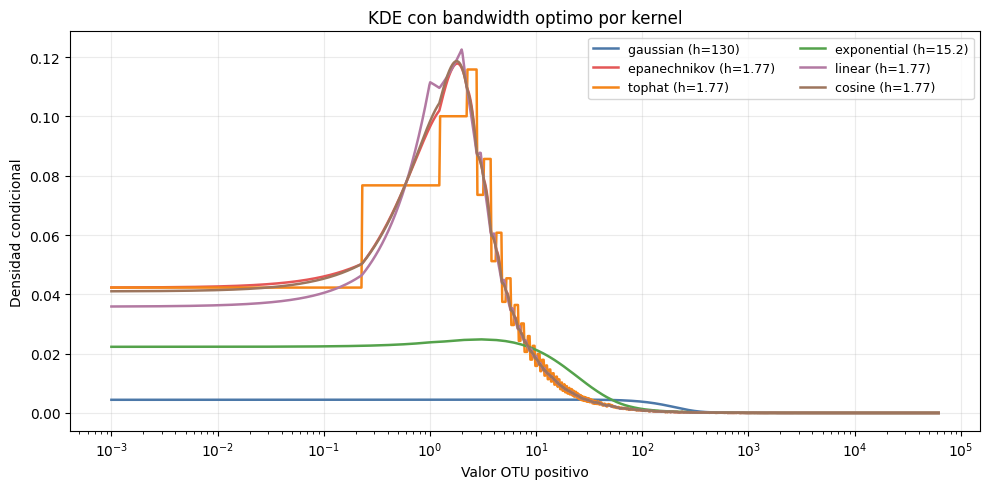

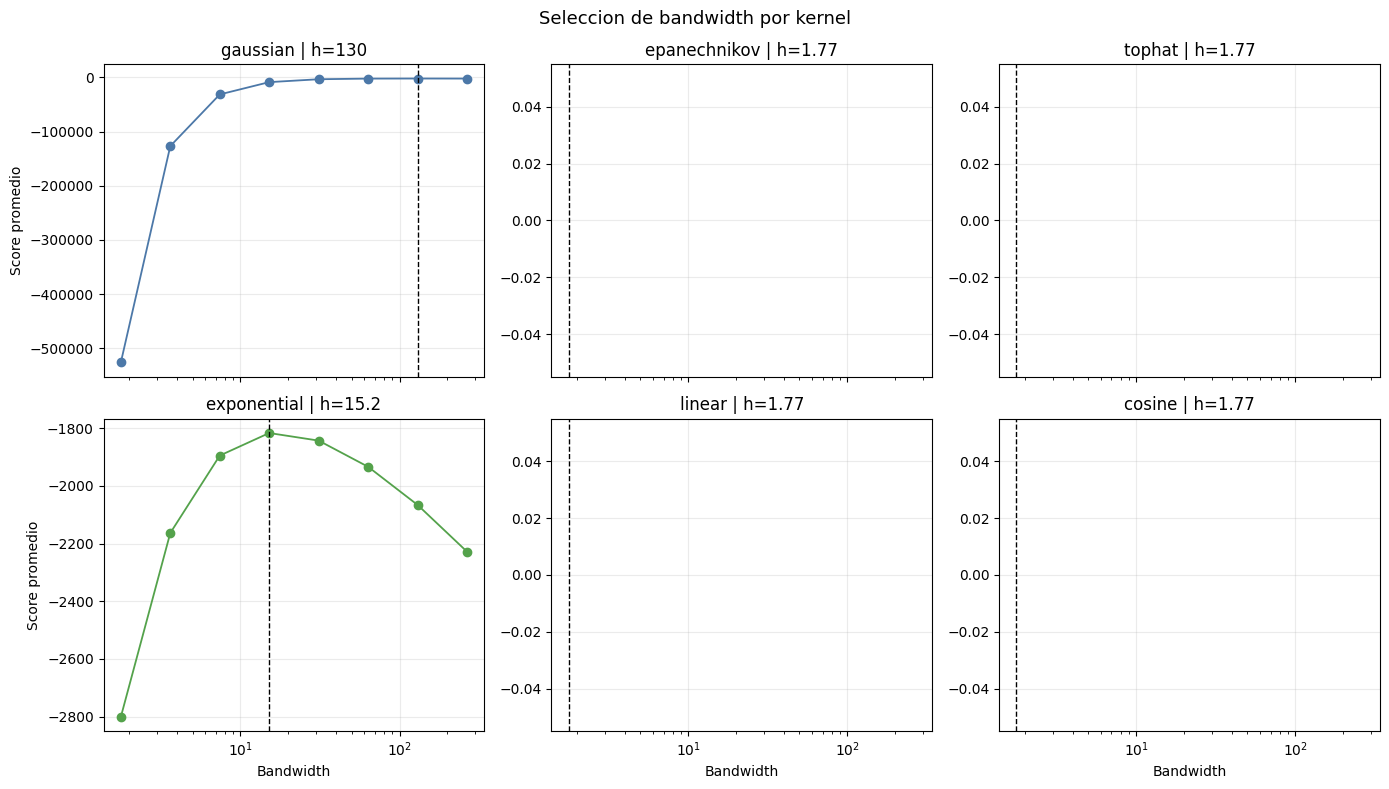

In [25]:
bandwidth_outputs = bandwidth_estimation_from_loaded(
    dfs=dfs,
    data_df_name="otu_data_converted",
    cv_subsample=1000,
    cv_folds=3,
    cv_bw_grid=8,
    grid_size=1000,
    verbose=True,
)
